# End-to-End E-Commerce Sales Analytics Dashboard

## Project Objective

This project aims to analyze e-commerce sales data to uncover insights related to sales performance, profitability, customer behavior, product trends, and regional performance. The findings will help support data-driven business decisions.

# Business Questions

The following questions will guide the analysis:

1. Which product categories generate the highest sales?
2. Which categories are the most profitable?
3. Which regions contribute the most revenue?
4. How do sales change over time?
5. Which products generate the highest profit?
6. Which products are causing losses?
7. What recommendations can improve business performance?

# Import Libraries

The required Python libraries are imported for data manipulation, analysis, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

The Superstore dataset is loaded into a Pandas DataFrame for analysis.

In [2]:
df = pd.read_csv('/content/superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Dataset Overview

Understanding the size and structure of the dataset before beginning analysis.

In [3]:
print("Rows and Columns:", df.shape)

df.columns

Rows and Columns: (9994, 21)


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [4]:
df.shape

(9994, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Data Quality Assessment

Checking for missing values and duplicate records.

In [7]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [8]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

No missing values were found in the dataset.
No duplicate records were identified.
The dataset is suitable for analysis.

## Exploratory Data Analysis  (EDA)

### Question 1

Which category generates the highest sales?

In [9]:
df.groupby('Category')['Sales'].sum()

,Sales
Category,
Furniture,741999.7953
Office Supplies,719047.0320
Technology,836154.0330


## Insight

Technology generated the highest sales revenue (₹836,154), followed by Furniture and Office Supplies.

This indicates that technology products are the primary revenue drivers for the business and contribute significantly to overall sales performance.

## Question 2

Which product category generates the highest profit?

Analyzing profit by category helps identify which product groups contribute most to business profitability.

In [10]:
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


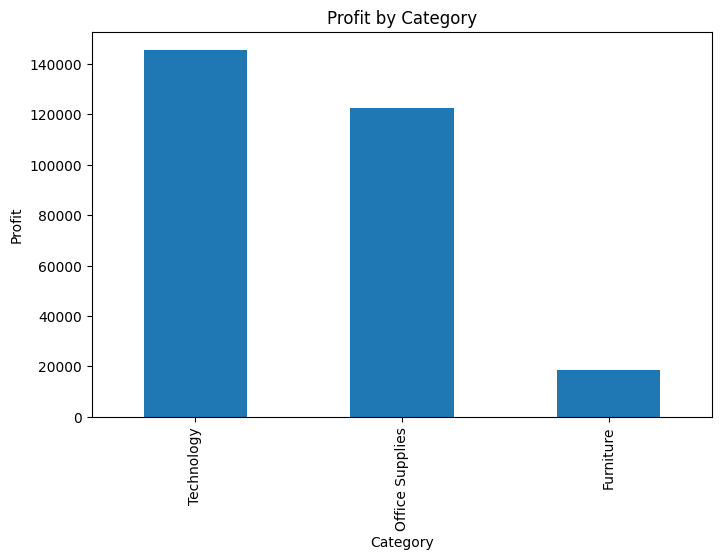

In [11]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_profit.plot(kind='bar')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

## Insight

Technology generated the highest profit, followed by Office Supplies.

Furniture produced the lowest profit despite having strong sales, indicating lower profit margins compared to other categories.

## Question 3

Which region contributes the highest sales revenue?

Regional analysis helps identify high-performing markets and supports location-based business strategies.

In [12]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


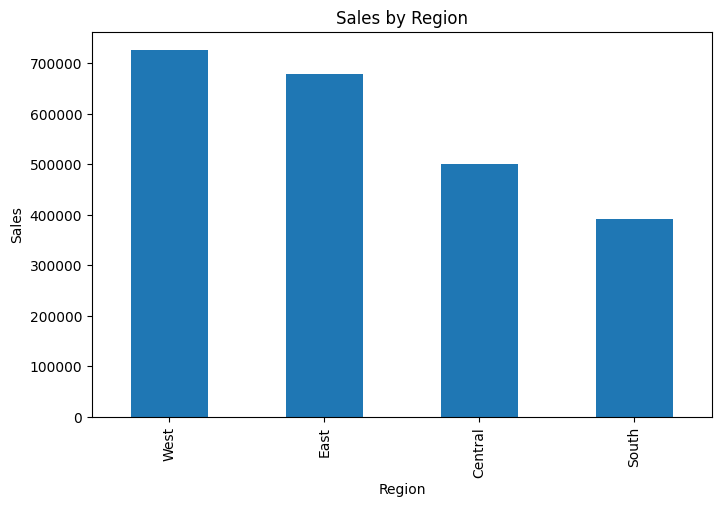

In [13]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

## Insight

The West region generated the highest sales revenue, followed closely by the East region.

The South region recorded the lowest sales, suggesting potential opportunities for market expansion and targeted marketing efforts.

## Question 4

How have sales changed over time?

Analyzing sales trends over time helps identify growth patterns, seasonality, and periods of strong or weak business performance.

In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [15]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.head()

,Sales
Order Date,
2014-01,14236.895
2014-02,4519.892
2014-03,55691.009
2014-04,28295.345
2014-05,23648.287


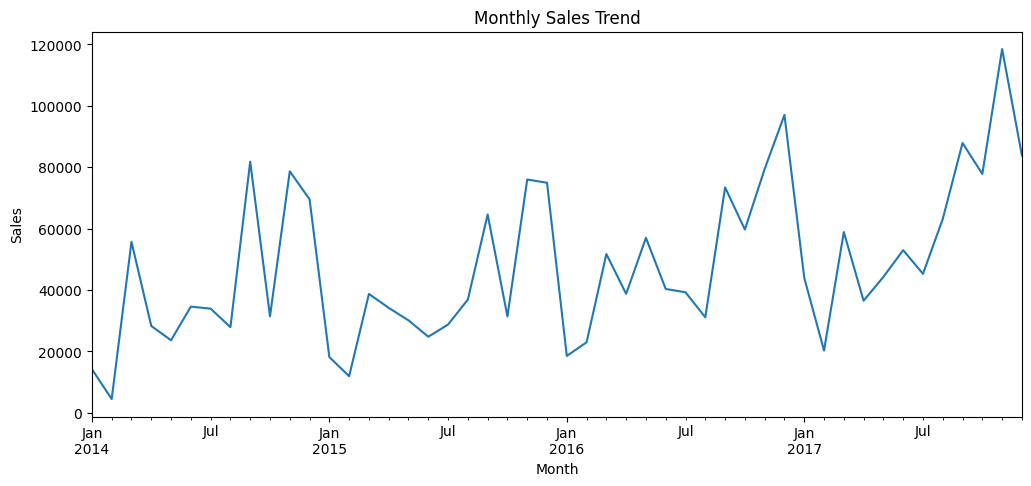

In [16]:
monthly_sales.plot(figsize=(12,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

## Insight

Monthly sales fluctuate throughout the period, indicating seasonal variations in customer purchasing behavior.

However, the overall trend shows growth over time, with the highest sales observed towards the end of 2017. This suggests that the business experienced increasing revenue and stronger sales performance over the years.

## Question 5

Which products generate the highest profit?

Identifying top-performing products helps the business understand which products contribute the most to profitability and should be prioritized for promotion and inventory planning.

In [17]:
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

top_products

,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766
Ativa V4110MDD Micro-Cut Shredder,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,3696.2820
Ibico EPK-21 Electric Binding System,3345.2823


## Insight

The Canon imageCLASS 2200 Advanced Copier was the most profitable product, generating over $25,000 in profit.

Several copier, printer, and office equipment products appear among the top-performing items, indicating that high-value technology products contribute significantly to overall profitability.

The company should consider promoting these products and maintaining sufficient inventory levels to maximize profit.

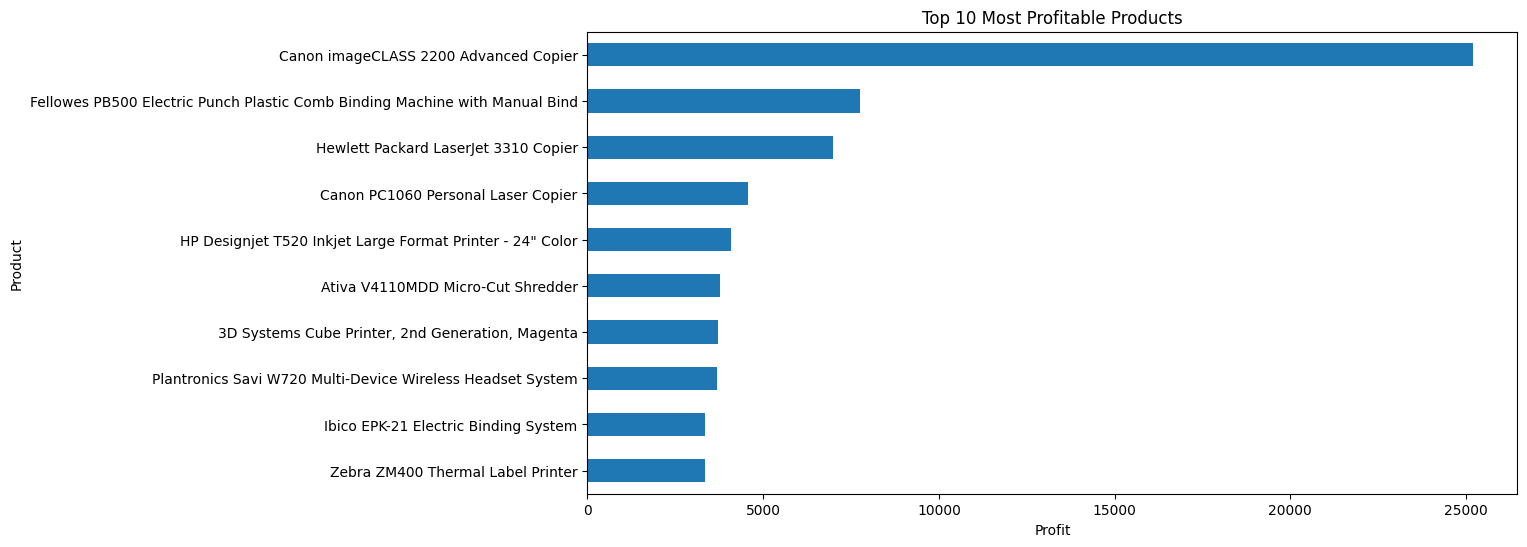

In [18]:
plt.figure(figsize=(12,6))
top_products.sort_values().plot(kind='barh')
plt.title('Top 10 Most Profitable Products')
plt.xlabel('Profit')
plt.ylabel('Product')
plt.show()

## Question 6

Which products generate the highest losses?

Identifying loss-making products helps the business review pricing strategies, discounts, and operational efficiency.

In [19]:
loss_products = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)

loss_products

,Profit
Product Name,
Cubify CubeX 3D Printer Double Head Print,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.1156
Bush Advantage Collection Racetrack Conference Table,-1934.3976
GBC DocuBind P400 Electric Binding System,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,-1811.0784
Martin Yale Chadless Opener Electric Letter Opener,-1299.1836
Balt Solid Wood Round Tables,-1201.0581


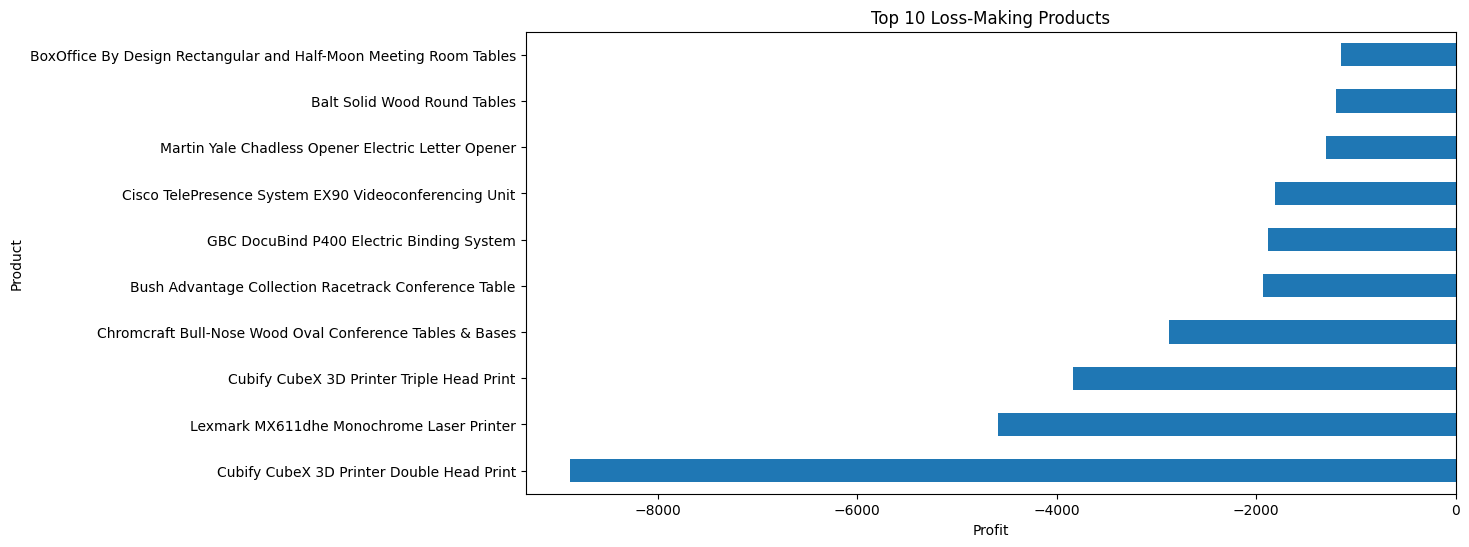

In [20]:
plt.figure(figsize=(12,6))
loss_products.plot(kind='barh')
plt.title('Top 10 Loss-Making Products')
plt.xlabel('Profit')
plt.ylabel('Product')
plt.show()

## Insight

The Cubify CubeX 3D Printer Double Head Print generated the highest loss, resulting in a negative profit of approximately $8,880.

Several conference tables, printers, and office equipment products also contributed significant losses.

The company should investigate pricing strategies, discount policies, and operational costs associated with these products to reduce future losses.

## Question 7

Who are the top customers by sales revenue?

Customer analysis helps identify high-value customers who contribute significantly to overall revenue and may benefit from targeted retention strategies.

In [21]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_customers

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


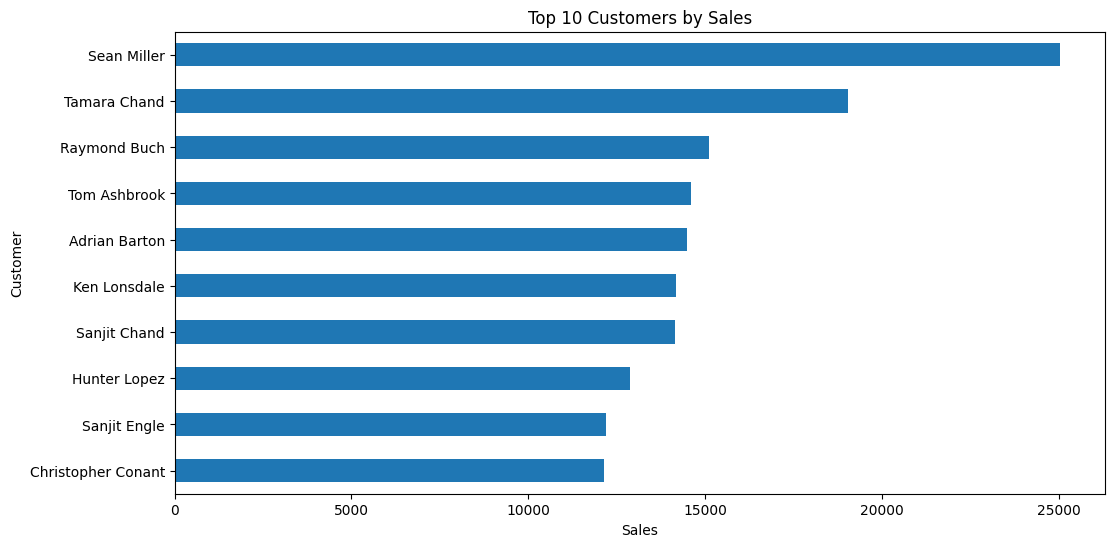

In [22]:
plt.figure(figsize=(12,6))
top_customers.sort_values().plot(kind='barh')
plt.title('Top 10 Customers by Sales')
plt.xlabel('Sales')
plt.ylabel('Customer')
plt.show()

## Insight

Sean Miller was the highest revenue-generating customer, contributing over $25,000 in sales.

The top 10 customers account for a significant portion of total revenue, highlighting the importance of customer retention and relationship management.

The business should focus on maintaining strong relationships with these high-value customers through loyalty programs and personalized marketing initiatives.

## Question 8

How does discounting affect profitability?

Understanding the relationship between discounts and profit helps evaluate pricing strategies and identify opportunities to improve margins.

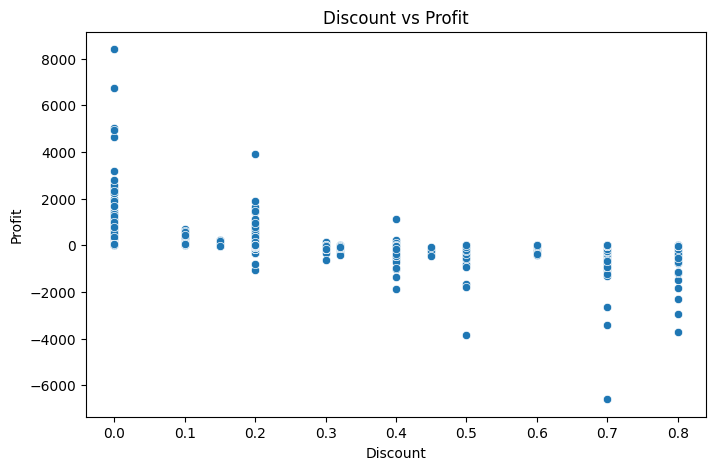

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit')
plt.title('Discount vs Profit')
plt.show()

## Insight

The scatter plot shows a negative relationship between discount levels and profitability.

Orders with little or no discount tend to generate higher profits, while heavily discounted orders are more likely to result in lower profits or losses.

This suggests that excessive discounting may negatively impact profit margins and should be carefully monitored by the business.

# Key Findings

1. Technology generated the highest sales revenue and profit among all categories.
2. The West region was the strongest-performing region in terms of sales.
3. Monthly sales showed an overall upward trend from 2014 to 2017.
4. High-value technology products contributed significantly to overall profitability.
5. Several products generated substantial losses despite generating sales.
6. A small group of customers contributed a large share of total revenue.
7. Higher discount levels were generally associated with lower profitability.

# Business Recommendations

1. Increase focus on high-performing technology products to maximize revenue and profit.
2. Review pricing and discount strategies for loss-making products.
3. Expand sales and marketing efforts in underperforming regions.
4. Strengthen relationships with top customers through loyalty and retention programs.
5. Monitor discount policies to protect profit margins and reduce losses.
6. Conduct further analysis on products with consistently negative profits.

# Executive Summary

This project analyzed e-commerce sales data to uncover insights related to sales performance, profitability, customer behavior, and regional trends.

The analysis revealed that Technology is the most valuable product category in terms of both sales and profit. The West region generated the highest sales revenue, while monthly sales displayed overall growth throughout the analyzed period.

Product-level analysis identified several highly profitable products as well as products responsible for significant losses. Customer analysis highlighted a small group of high-value customers who contribute substantially to revenue.

The discount analysis indicated that excessive discounting may negatively impact profitability. Based on these findings, the business can improve performance through better pricing strategies, targeted customer retention efforts, and increased focus on profitable products.

# Conclusion

This project successfully analyzed e-commerce sales data using Python, Pandas, Matplotlib, and Seaborn.

The findings provide actionable business insights that can help improve profitability, optimize product strategy, strengthen customer relationships, and support data-driven decision-making.

This project demonstrates skills in:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Analytics
- Insight Generation
- Data Storytelling